In [1]:
import utils.paths as d
import utils.utils as u
import utils.functions as f

from utils.utils import PALETTE, LEVEL1_COLORS, L2_COLORS
from utils.functions import apply_palette, show_palette

from spatialdata.models import TableModel
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import spatialdata as sd
import spatialdata_plot
import zarr
import anndata as ad
import os
import warnings
import pandas as pd
warnings.filterwarnings("ignore", category=UserWarning)

print("Python version:", __import__('sys').version)
for m in (sc, sd, spatialdata_plot, zarr, ad):
    print(f"{m.__name__} version: {m.__version__}")

c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python version: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
scanpy version: 1.11.5
spatialdata version: 0.7.3
spatialdata_plot version: 0.4.0
zarr version: 3.1.6
anndata version: 0.12.19


C:\Users\sevco\AppData\Local\Temp\ipykernel_4424\1096604312.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"{m.__name__} version: {m.__version__}")
C:\Users\sevco\AppData\Local\Temp\ipykernel_4424\1096604312.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print(f"{m.__name__} version: {m.__version__}")


In [5]:
INPUT_DIR = d.preprocessed_dir
PROSEG_DIR = d.project_root / "data_raw" / "proseg_out_fixed_v2"

In [4]:
adata = sc.read_h5ad(os.path.join(INPUT_DIR, "adata_annotated_refined_10.h5ad"))

In [6]:
wt_1 = sd.read_zarr(PROSEG_DIR / "C1" / "proseg-output.zarr")
wt_2 = sd.read_zarr(PROSEG_DIR / "C2" / "proseg-output.zarr")
wt_3 = sd.read_zarr(PROSEG_DIR / "C3" / "proseg-output.zarr")
wt_4 = sd.read_zarr(PROSEG_DIR / "C4" / "proseg-output.zarr")
mut_1 = sd.read_zarr(PROSEG_DIR / "C5" / "proseg-output.zarr")
mut_2 = sd.read_zarr(PROSEG_DIR / "C6" / "proseg-output.zarr")
mut_3 = sd.read_zarr(PROSEG_DIR / "C7" / "proseg-output.zarr")    
mut_4 = sd.read_zarr(PROSEG_DIR / "C8" / "proseg-output.zarr")

sdatas = {
    "C1": wt_1,  "C2": wt_2,  "C3": wt_3,  "C4": wt_4,
    "C5": mut_1, "C6": mut_2, "C7": mut_3, "C8": mut_4,
}

In [7]:
samples = [f'{g}_{i}' for g in ['wt', 'mut'] for i in range(1, 5)]
sdatas = {s: globals()[s] for s in samples}      # or: {s: sd.read_zarr(path) for s, path in paths.items()}

def link_table(sdata, ad_s, id_col='cell', shapes='cell_boundaries', name='table_annot'):
    shp = sdata[shapes]
    ad = ad_s.copy()
    ad.uns.pop('spatialdata_attrs', None)
    ad.obs['region_sd'] = pd.Categorical([shapes] * ad.n_obs)
    ad.obs['instance_id'] = ad.obs[id_col].astype(shp.index.dtype).values
    ids = ad.obs['instance_id']
    c = shp.loc[ids[ids.isin(shp.index)].values].geometry.centroid
    m = ids.isin(shp.index).values
    d = np.hypot(c.x.values - ad.obs['centroid_x'].values[m], c.y.values - ad.obs['centroid_y'].values[m])
    sdata[name] = TableModel.parse(ad, region=shapes, region_key='region_sd', instance_key='instance_id')
    return dict(n_cells=ad.n_obs, n_shapes=len(shp), unique=ids.is_unique,
                matched=round(m.mean(), 4), median_dist=round(float(np.median(d)), 3))

report = pd.DataFrame({s: link_table(sdatas[s], adata[adata.obs['sample'] == s]) for s in samples}).T
report

,n_cells,n_shapes,unique,matched,median_dist
wt_1,26871,27343,True,1.0,0.3
wt_2,24828,25154,True,1.0,0.345
wt_3,22654,23387,True,1.0,0.295
wt_4,30322,31126,True,1.0,0.311
mut_1,21469,21960,True,1.0,0.315
mut_2,23470,24114,True,1.0,0.295
mut_3,25948,26634,True,1.0,0.323
mut_4,25163,26055,True,1.0,0.322


In [8]:
wt_1 = sdatas["wt_1"]
wt_2 = sdatas["wt_2"]
wt_3 = sdatas["wt_3"]
wt_4 = sdatas["wt_4"]
mut_1 = sdatas["mut_1"]
mut_2 = sdatas["mut_2"]
mut_3 = sdatas["mut_3"]
mut_4 = sdatas["mut_4"]

In [48]:

# Keys match the values of cell_type_mapping EXACTLY (case + spacing matter)
PALETTE = {
  # ── Epithelial (greens) ──────────────────────────────────────────────────
  'Epithelial': {
    'Basal epithelial cells':                          '#0B4F2A',   # deep forest
    'Oral epithelial cells':                           '#2DB84C',   # vivid kelly
    'Glandular epithelial cells':                      '#558B2F',   # moss '#558B2F',
    'Dental epithelial cells':                         "#8FBE62",   # olive   '#7A7A1F', 
    'Signaling epithelial cells':                      '#7A7A1F',   # light grass A6E36B
    'Keratinized epithelial cells':                    '#9DB39A',   # sage
    'Differentiated epithelial cells':                 "#D1E9B6"},  # pale green
  # ── Mesenchymal (purples / magenta) ──────────────────────────────────────
  'Mesenchymal': {
    'Mesenchymal progenitor cells':                    '#5B21B6',   # deep violet
    'Craniofacial developmental mesenchymal cells':    '#8B5CF6',   # violet
    'ECM producing mesenchymal cells':                 '#C026D3',   # magenta
    'Outer fibroperiosteal cells':                     '#C4B5FD'},  # lavender
  # ── Dental mesenchyme (golds; follicle -> papilla) ───────────────────────
  'Dental mesenchyme': {
    'Dental follicle mesenchymal cells':               '#8C6D1F',   # bronze
    'Dental follicle cells':                           '#C9A227',   # old gold
    'Dental follicle signaling niche':                 '#F2C94C',   # gold
    'Dental papilla cells':                            '#FFE699',   # pale butter
    'Mut-specific dental cells':                       '#1A1A1A'},  # near-black – highlight
  # ── Neural crest (warm grey) ─────────────────────────────────────────────
  'Neural crest': {
    'Neural crest':                                    '#78716C'},
  # ── Osteogenic (blues; progenitor light -> mature navy) ──────────────────
  'Osteogenic': {
    'Osteogenic progenitors':                          '#22D3EE',   # cyan
    'Early osteoblasts':                               '#14B8A6',   # teal
    'Matrix-secreting osteoblast lineage cells':       '#0F766E',   # dark teal
    'Pre-osteocytes / diff. osteoblast lineage cells': '#134E4A'},  # deep teal
  # ── Muscle (browns) ──────────────────────────────────────────────────────
  'Muscle': {
    'Myogenic progenitor':                             '#C08A5B',   # tan
    'Skeletal muscle':                                 '#6D3B1E'},  # dark brown
  # ── Chondrogenic (reds) ──────────────────────────────────────────────────
  'Chondrogenic': {
    'Chondrocytes':                                    '#FF1744',   # vivid scarlet
    'Hypertrophic chondrocytes':                       '#B71C1C'},  # deep red
  # ── Vascular / mural (teals; EC light -> SMC dark) ───────────────────────
  'Vascular': {
    'Endothelial cells':                               '#42A5F5',   # mid blue
    'Lymphatic endothelial cells':                     '#8FD3FF',   # light sky
    'perivascular smooth muscle cells':                '#084EFF',   # vivid royal
    'Vascular smooth muscle cells':                    '#0B1F5C'},  # deep navy
  # ── Immune (oranges + mast rose) ─────────────────────────────────────────
  'Immune': {
    'Macrophages':                                     '#FF8A3D',   # orange
    'Osteoclasts':                                     '#FF6B9D',   # burnt orange C2410C
    'Mast cells':                                      '#C2410C'},  # rose FF6B9D
}
 
LEVEL1_COLORS = {
    'Epithelial':        '#2DB84C',
    'Mesenchymal':       '#8B5CF6',
    'Dental mesenchyme': '#C9A227',
    'Neural crest':      '#78716C',
    'Osteogenic':        '#14B8A6',
    'Muscle':            '#6D3B1E',
    'Chondrogenic':      '#FF1744',
    'Vascular':          '#0B1F5C',
    'Immune':            '#FF8A3D',
}
 
# flat lookups
L2_COLORS = {t: c for g in PALETTE.values() for t, c in g.items()}
L2_TO_L1  = {t: g for g, d in PALETTE.items() for t in d}
L2_ORDER  = list(L2_COLORS)   # palette order = grouped by lineage
 

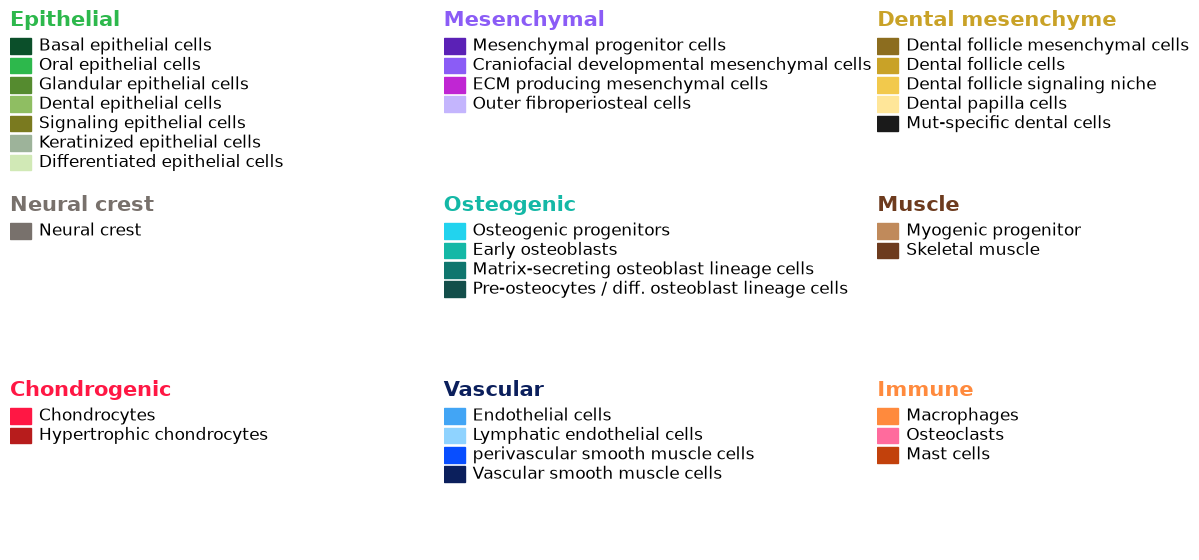

In [49]:
def show_palette(ncols=3):
    n = len(PALETTE)
    nrows = -(-n // ncols)                      # ceil division
    max_len = max(len(d) for d in PALETTE.values())
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4 * ncols, 0.2 * max_len * nrows + 0.5 * nrows))
    axes = axes.ravel()
    for ax, (g, d) in zip(axes, PALETTE.items()):
        ax.set_title(g, color=LEVEL1_COLORS[g], weight='bold', fontsize=15, loc='left')
        for i, (t, c) in enumerate(d.items()):
            ax.add_patch(plt.Rectangle((0, -i), .08, .8, color=c))
            ax.text(.11, -i + .4, t.replace('_', ' '), va='center', fontsize=12)
        ax.set_xlim(0, 1); ax.set_ylim(-max_len + .5, 1)
    for ax in axes:
        ax.axis('off')                          # also hides unused panels
    plt.tight_layout(); plt.show()

show_palette(ncols=3)

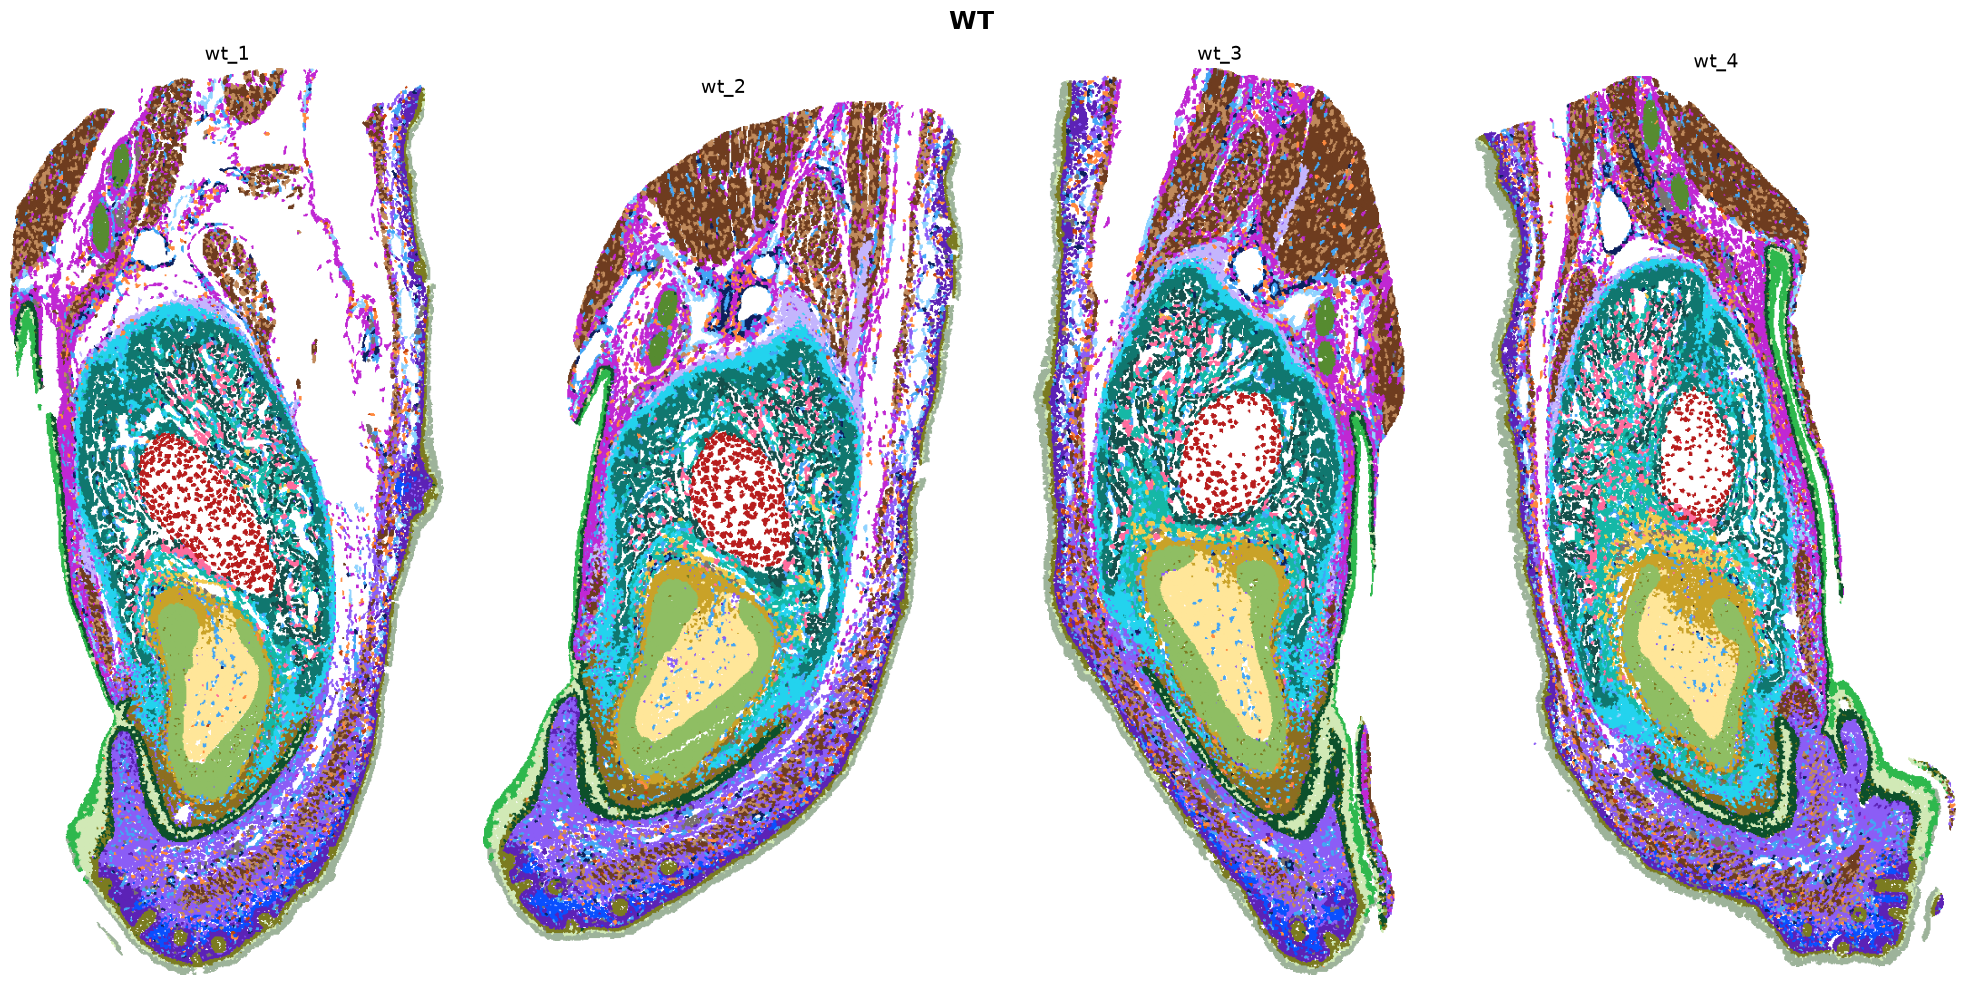

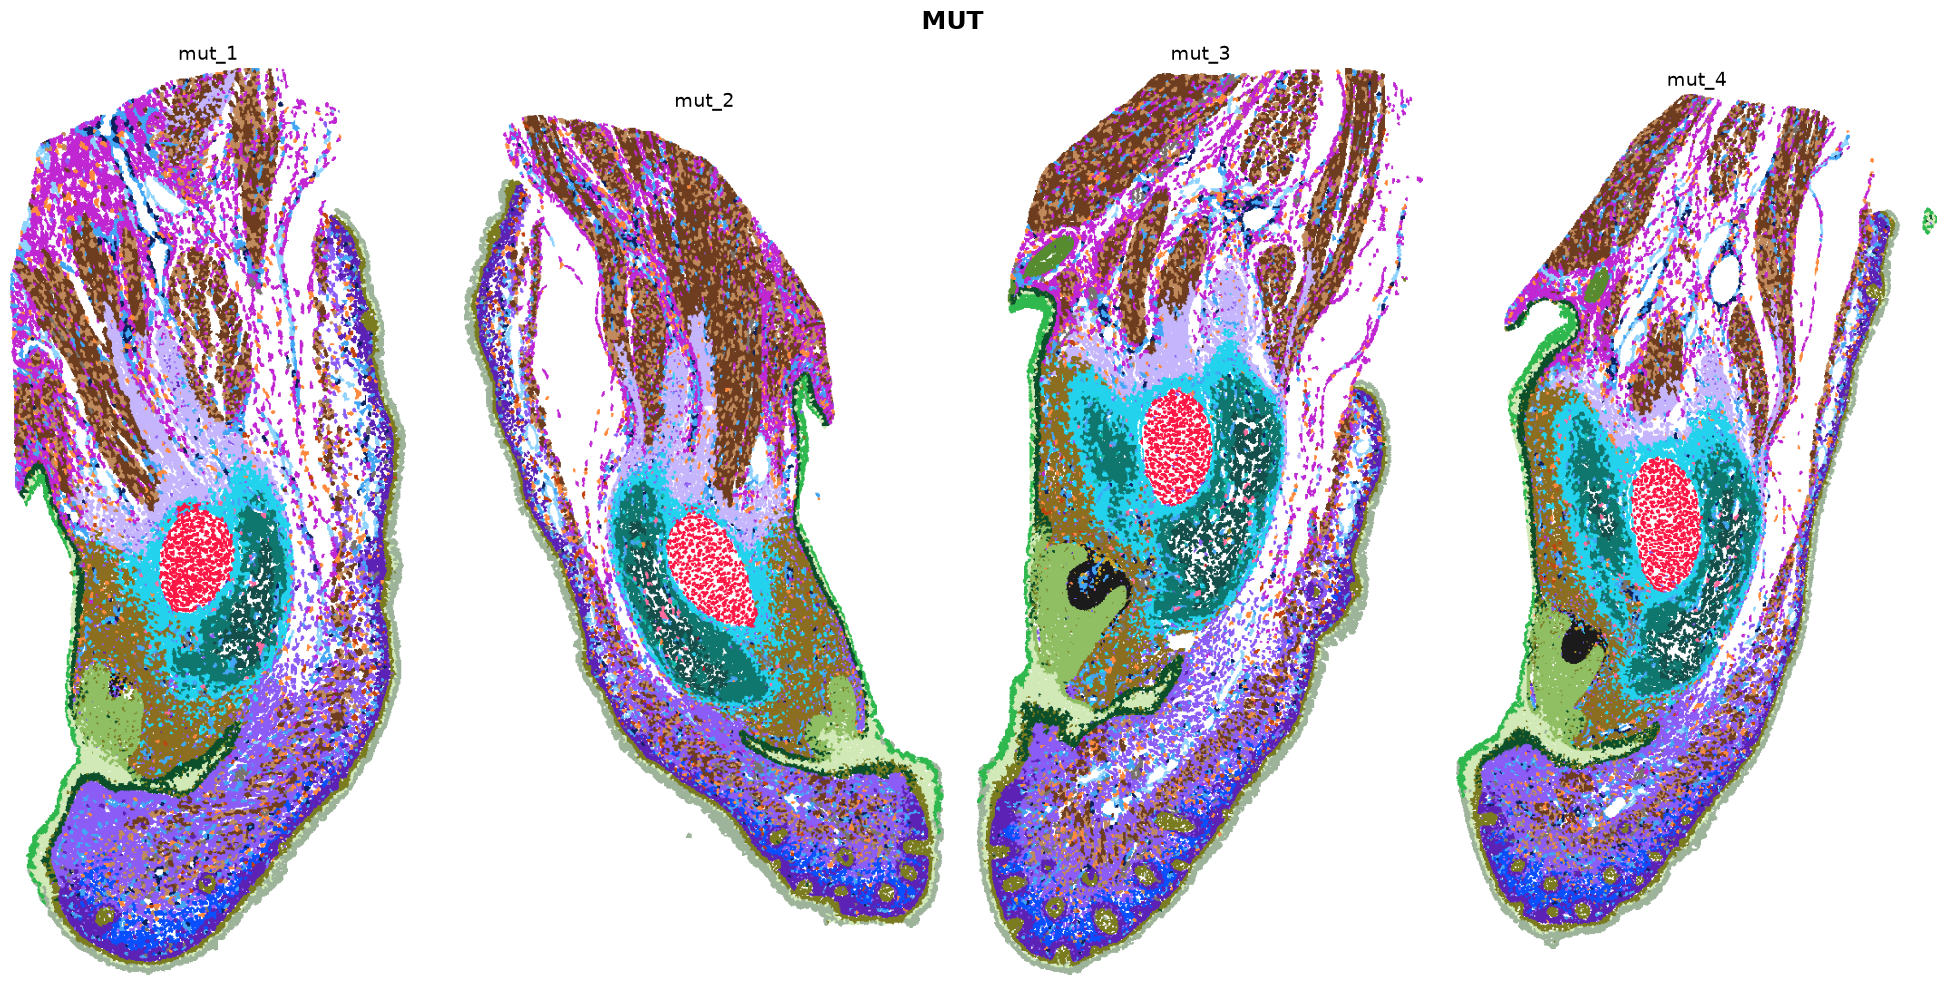

In [50]:
groups = [t for t in L2_COLORS if t in set(adata.obs['annotation'])]
palette = [L2_COLORS[t] for t in groups]

for cond in ['wt', 'mut']:
    fig, axes = plt.subplots(1, 4, figsize=(20, 10))
    for ax, i in zip(axes, range(1, 5)):
        s = f'{cond}_{i}'
        sdatas[s].pl.render_shapes('cell_boundaries', color='annotation', table_name='table_annot',
                                   groups=groups, palette=palette).pl.show(ax=ax)
        if ax.get_legend(): ax.get_legend().remove()
        ax.set_axis_off()
        ax.set_title(s, fontsize=14)
    fig.suptitle(cond.upper(), fontsize=18, weight='bold')
    plt.tight_layout(); plt.show()

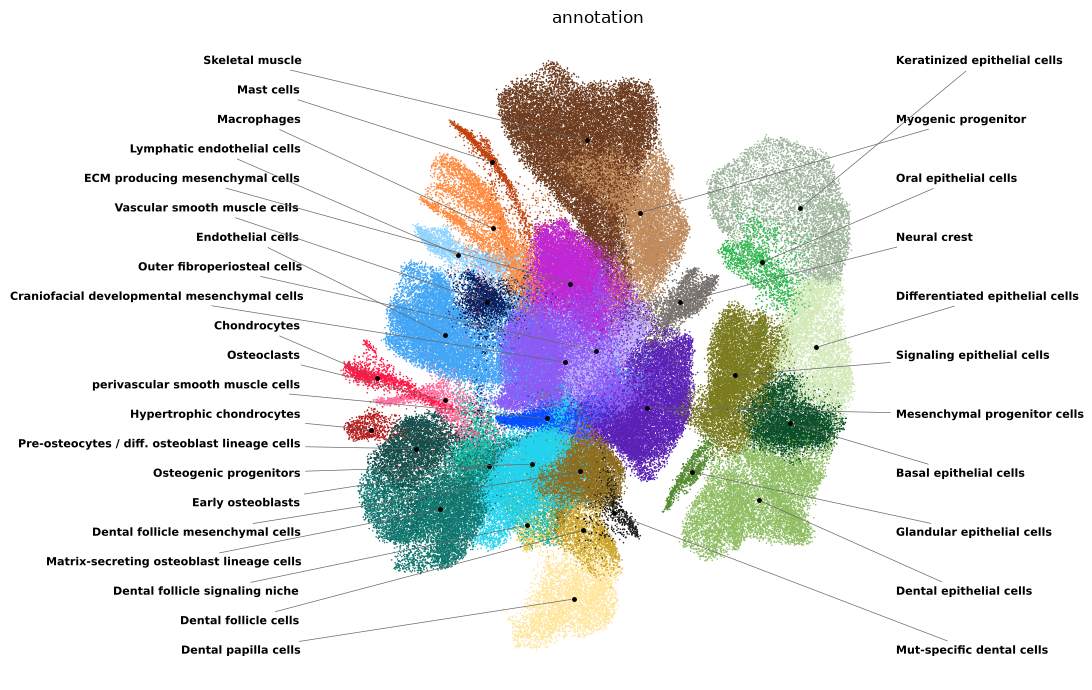

In [51]:
import matplotlib.patheffects as pe

key = 'annotation'
cats = adata.obs[key].cat.categories
fig, ax = plt.subplots(figsize=(11, 7))
sc.pl.umap(adata, color=key, size=5, frameon=False, legend_loc=None, show=False, ax=ax,
           palette=[L2_COLORS[t] for t in cats])

xy = pd.DataFrame(adata.obsm['X_umap'], columns=['x', 'y'], index=adata.obs_names)
cent = xy.groupby(adata.obs[key], observed=True).median()
(x0, y0), (x1, y1) = xy.min(), xy.max()
xmid, pad = (x0 + x1) / 2, 0.08 * (x1 - x0)

for side, sub in cent.groupby(cent.x >= xmid):
    sub = sub.sort_values('y')
    ys = np.linspace(y0, y1, len(sub)) if len(sub) > 1 else [sub.y.iloc[0]]
    lx, ha = (x1 + pad, 'left') if side else (x0 - pad, 'right')
    for (t, r), ly in zip(sub.iterrows(), ys):
        ax.annotate(t.replace('_', ' '), xy=(r.x, r.y), xytext=(lx, ly), ha=ha, va='center',
                    fontsize=8, weight='bold', 
                    # color=L2_COLORS.get(t, 'k'),
                    path_effects=[pe.withStroke(linewidth=1.5, foreground='w')],
                    arrowprops=dict(arrowstyle='-', color='0.4', lw=0.5,
                                    connectionstyle='angle,angleA=0,angleB=90,rad=0' if False else 'arc3'))
        ax.plot(r.x, r.y, 'o', ms=2.5, color='k')          # anchor dot at cluster center

ax.set_xlim(x0 - 4 * pad, x1 + 4 * pad)
ax.set_title(key); plt.tight_layout(); plt.show()

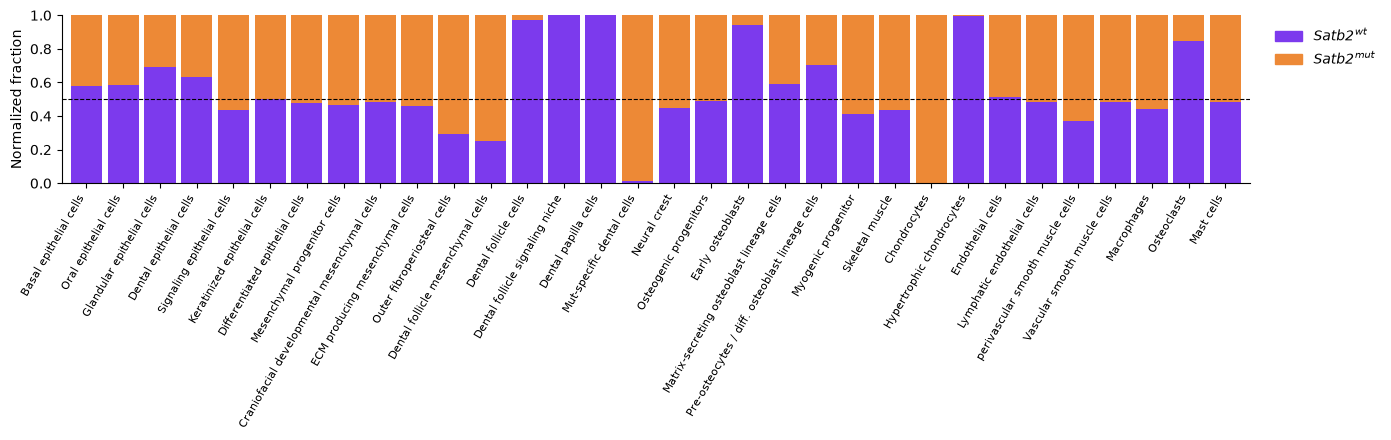

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

cluster_key = "annotation"
cond_key = "condition"   # "+/+" / "-/-"

ct = pd.crosstab(adata.obs[cluster_key], adata.obs[cond_key])
order = [t for t in L2_COLORS if t in ct.index] + [t for t in ct.index if t not in L2_COLORS]
ct = ct.loc[order, ["wt", "mut"]]

# normalize to total cells per condition, then to 1 within each cluster
norm = ct.div(ct.sum(axis=0), axis=1)
norm = norm.div(norm.sum(axis=1), axis=0)

colors = {"wt": "#7C3AED", "mut": "#ED8936"}
labels = {"wt": r"$\it{Satb2}^{wt}$", "mut": r"$\it{Satb2}^{mut}$"}

fig, ax = plt.subplots(figsize=(14, 4.5))
norm.plot(kind="bar", stacked=True, ax=ax, width=0.85,
          color=[colors[c] for c in norm.columns], legend=False)

ax.axhline(0.5, color="black", lw=0.8, ls="--")
ax.set_ylim(0, 1)
ax.set_ylabel("Normalized fraction")


for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=colors[c]) for c in norm.columns]
ax.legend(handles, [labels[c] for c in norm.columns],
          frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xlabel("")
ax.set_xticklabels([t.replace("_", " ") for t in norm.index], rotation=60, ha="right", fontsize=8)
for lab in ax.get_xticklabels():
    lab.set_color(
        # L2_COLORS.get(lab.get_text().replace(" ", "_"), "k")
        color="black"
        )
fig.tight_layout()
plt.show()